# Stats 143 Convolution Neural Network Design




Allison Lynn, Ryan So, Cynthia Du, Bryan Mui, Mian Xie


### Using a CNN to preserve spatial structure of images

In [ ]:
#----------------Load Packages-----------------------

import pandas as pd
from tensorflow.keras.datasets import cifar10
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import numpy as np
import os
from sklearn.model_selection import ParameterGrid
import random
import torch
from torch import nn
import copy
import hashlib
import torch.nn.functional as F
import optuna
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import random_split

ModuleNotFoundError: No module named 'optuna'

In [ ]:
#-------------Get Training and Testing Data------------------------

# Data Transformations for augmentation
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Augmentation to generalize better
    transforms.RandomCrop(32, padding=4),  # Cropping for spatial variability
    transforms.ToTensor(),  # Converting images to tensors
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalizing pixel values
])

# CIFAR-10 Dataset
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Data Loaders for batching
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

In [ ]:
#---------------Defining Device--------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

In [ ]:
#------------------Defining Training and Validation Datasets-------------------

train_size = 45000
val_size = 5000

# cannot use test as validation
train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)

In [ ]:
#-----------DataFrame Display Formatting--------------

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", "{:.4f}".format)

In [ ]:
#-----------Defining Label Names-------------

label_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

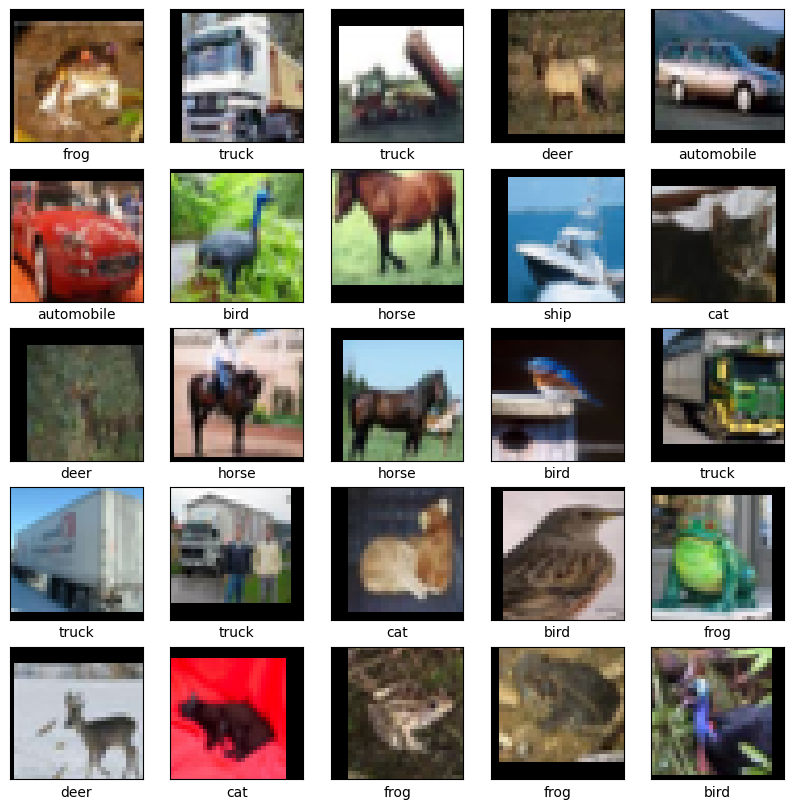

In [ ]:
#-------------Preliminary View of Images & Classifications------------------

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([]); plt.yticks([])
    plt.grid(False)

    img, label = train_dataset[i]   # unpack tuple

    # img is a Tensor [3,32,32] because of transforms; convert to [32,32,3]
    img = img.permute(1, 2, 0)

    # undo your normalization (mean=0.5, std=0.5) so it displays correctly
    img = img * 0.5 + 0.5
    img = img.clamp(0, 1)

    plt.imshow(img)
    plt.xlabel(label_names[label])

plt.show()


In [ ]:
## note: run everything up to manual architecture search before running any other code

# Exploring Manual Hyperparameter Tuning

Hyperparameters:
- dropout
- max pooling vs average pooling
- epochs
- activation fucntions (ReLu)
- optimizer (base = Adam)
- number of convolution layers/size

### Pooling + Kernel Size

MAX POOLING

In [ ]:
#--------------------Base Model 1---------------------------
  # 2 convolution layers
  # ReLu activation function
  # Max pooling
  # 3 x 3 kernel → focus on fine, local details (edges, corners)
  # Architecture:
    # 32×32 (pixels) → Conv3×3 (padding=1) → 32×32 → MaxPool → 16×16 → Conv3×3 (padding=1) → 16×16 → MaxPool → 8×8

model1 = nn.Sequential(
    # Convolutional feature extractor
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),          # 32×32 → 16×16

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),          # 16×16 → 8×8

    # Flatten for fully connected layers
    nn.Flatten(),

    # Classifier
    nn.Linear(64 * 8 * 8, 512),
    nn.ReLU(),
    nn.Linear(512, 10)
)

In [ ]:
#--------------Model 2------------------
  # 2 convolution layers
  # ReLu activation function
  # Max pooling
  # 5 x 5 kernel → capture broader patterns (larger textures, shapes)
  # Architecture:
    # 32×32 (pixels) → Conv5x5 (padding = 2) → 30×30 → MaxPool → 15×15 → Conv5x5 (padding = 2) → 13×13 → MaxPool → 6×6
model2 = nn.Sequential(
    # Convolutional feature extractor
    nn.Conv2d(3, 32, kernel_size=5, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, kernel_size=5, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # Flatten for fully connected layers
    nn.Flatten(),

    # Classifier
    nn.Linear(64 * 8 * 8, 512),
    nn.ReLU(),
    nn.Linear(512, 10)
)

AVERAGE POOLING

In [ ]:
#--------------Model 3------------------
  # 2 convolution layers
  # ReLu activation function
  # Average pooling
  # 3 x 3 kernel → focus on fine, local details (edges, corners)
  # Architecture:
    # 32×32 (pixels) → Conv3×3 (padding=1) → 32×32 → AvgPool → 16×16 → Conv3×3 (padding=1) → 16×16 → AvgPool → 8×8
model3 = nn.Sequential(
    # Convolutional feature extractor
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.AvgPool2d(2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.AvgPool2d(2),

    # Flatten for fully connected layers
    nn.Flatten(),

    # Classifier
    nn.Linear(64 * 8 * 8, 512),
    nn.ReLU(),
    nn.Linear(512, 10)
)

In [ ]:
#--------------Model 4------------------
  # 2 convolution layers
  # ReLu activation function
  # Average pooling
  # 5 x 5 kernel → capture broader patterns (larger textures, shapes)
  # Architecture:
    # 32×32 (pixels) → Conv5x5 (padding = 2) → 30×30 → AvgPool → 15×15 → Conv5x5 (padding = 2) → 13×13 → AvgPool → 6×6
model4 = nn.Sequential(
    # Convolutional feature extractor
    nn.Conv2d(3, 32, kernel_size=5, padding=2),
    nn.ReLU(),
    nn.AvgPool2d(2),

    nn.Conv2d(32, 64, kernel_size=5, padding=2),
    nn.ReLU(),
    nn.AvgPool2d(2),

    # Flatten for fully connected layers
    nn.Flatten(),

    # Classifier
    nn.Linear(64 * 8 * 8, 512),
    nn.ReLU(),
    nn.Linear(512, 10)
)

#### Testing Models

In [ ]:
#--------------Model 1----------------------

# ---- device ----
model1 = model1.to(device)

# ---- loss + optimizer ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model1.parameters(), lr=1e-3)

train_acc_history1 = []
test_acc_history1 = []
train_loss_history1 = []
test_loss_history1 = []

# ---- run training + testing ----
epochs = 20
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(
        model1, trainloader, optimizer, criterion, device
    )
    test_loss, test_acc = evaluate(
        model1, testloader, criterion, device
    )

    train_loss_history1.append(train_loss)
    test_loss_history1.append(test_loss)
    train_acc_history1.append(train_acc)
    test_acc_history1.append(test_acc)

    print(f"Epoch {epoch:02d} | "
          f"train acc {train_acc:.4f} | test acc {test_acc:.4f}")

Epoch 01 | train acc 0.4601 | test acc 0.5505
Epoch 02 | train acc 0.6081 | test acc 0.6378
Epoch 03 | train acc 0.6639 | test acc 0.6684
Epoch 04 | train acc 0.7048 | test acc 0.6868


In [ ]:
plt.plot(train_acc_history1, label="training")
plt.plot(test_acc_history1, label="validation (test)")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

stablizes and even decreases at later epochs

In [ ]:
#---------------Model 2--------------------

# ---- device ----
model2 = model2.to(device)

# ---- loss + optimizer ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=1e-3)

train_acc_history2 = []
test_acc_history2 = []
train_loss_history2 = []
test_loss_history2 = []

# ---- run training + testing ----
epochs = 10
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(
        model2, trainloader, optimizer, criterion, device
    )
    test_loss, test_acc = evaluate(
        model2, testloader, criterion, device
    )

    train_loss_history2.append(train_loss)
    test_loss_history2.append(test_loss)
    train_acc_history2.append(train_acc)
    test_acc_history2.append(test_acc)

    print(f"Epoch {epoch:02d} | "
          f"train acc {train_acc:.4f} | test acc {test_acc:.4f}")

In [ ]:
#---------------Model 3--------------------

# ---- device ----
model3 = model3.to(device)

# ---- loss + optimizer ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model3.parameters(), lr=1e-3)

train_acc_history3 = []
test_acc_history3 = []
train_loss_history3 = []
test_loss_history3 = []

# ---- run training + testing ----
epochs = 10
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(
        model3, trainloader, optimizer, criterion, device
    )
    test_loss, test_acc = evaluate(
        model3, testloader, criterion, device
    )

    train_loss_history3.append(train_loss)
    test_loss_history3.append(test_loss)
    train_acc_history3.append(train_acc)
    test_acc_history3.append(test_acc)

    print(f"Epoch {epoch:02d} | "
          f"train acc {train_acc:.4f} | test acc {test_acc:.4f}")

In [ ]:
#---------------Model 4--------------------

# ---- device ----
model4 = model4.to(device)

# ---- loss + optimizer ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model4.parameters(), lr=1e-3)

train_acc_history4 = []
test_acc_history4 = []
train_loss_history4 = []
test_loss_history4 = []

# ---- run training + testing ----
epochs = 10
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(
        model4, trainloader, optimizer, criterion, device
    )
    test_loss, test_acc = evaluate(
        model4, testloader, criterion, device
    )

    train_loss_history4.append(train_loss)
    test_loss_history4.append(test_loss)
    train_acc_history4.append(train_acc)
    test_acc_history4.append(test_acc)

    print(f"Epoch {epoch:02d} | "
          f"train acc {train_acc:.4f} | test acc {test_acc:.4f}")

In [ ]:
#-----------------cumulative plot-------------
plt.plot(test_acc_history1,  label="Test M1")

# Model 2
plt.plot(test_acc_history2,  label="Test M2")

# Model 3
plt.plot(test_acc_history3,  label="Test M3")

# Model 4
plt.plot(test_acc_history4,  label="Test M4")

plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

### Number of Convolution Layers (between 2 to 5)

In [ ]:
#--------------------Model 5---------------------------
  # 3 convolution layers
  # ReLu activation function
  # Max pooling
  # 3 x 3 kernel → focus on fine, local details (edges, corners)
  # Architecture:
    # 32×32 (pixels) → Conv3×3 (padding=1) → 32×32 → MaxPool → 16×16 → Conv3×3 (padding=1) → 16×16 → MaxPool → 8×8 → Conv3×3 (padding=1) → 8x8

model5 = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 32×32 → 32×32
    nn.ReLU(),
    nn.MaxPool2d(2),                              # 32×32 → 16×16

    nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 16×16 → 16×16
    nn.ReLU(),
    nn.MaxPool2d(2),                              # 16×16 → 8×8

    nn.Conv2d(64, 64, kernel_size=3, padding=1),  # 8×8 → 8×8
    nn.ReLU(),
    nn.MaxPool2d(2),                              # 8×8 → 4×4

    nn.Flatten(),                                 # 64×4×4 → 1024

    nn.Linear(1024, 512),                         # 1024 → 512
    nn.ReLU(),
    nn.Linear(512, 10)                            # 512 → 10
)


In [ ]:
# -------------------- Model 6 ---------------------------
# 4-convolution-layer CNN
# - 4 convolutional layers for hierarchical feature extraction
# - ReLU activation functions
# - Max pooling for spatial downsampling
# - 3×3 kernels focus on fine, local details (edges, corners)
#
# Architecture:
# 32×32 (pixels)
# → Conv3×3 (pad=1) → 32×32 → Conv3×3 (pad=1) → 32×32 → MaxPool → 16×16
# → Conv3×3 (pad=1) → 16×16 → Conv3×3 (pad=1) → 16×16 → MaxPool → 8×8
# → Flatten → Fully Connected → Output classes

model6 = nn.Sequential(
    # -------- Convolution Block 1 --------
    nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 32×32 → 32×32
    nn.ReLU(),
    nn.Conv2d(32, 32, kernel_size=3, padding=1),  # 32×32 → 32×32
    nn.ReLU(),
    nn.MaxPool2d(2),                              # 32×32 → 16×16

    # -------- Convolution Block 2 --------
    nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 16×16 → 16×16
    nn.ReLU(),
    nn.Conv2d(64, 64, kernel_size=3, padding=1),  # 16×16 → 16×16
    nn.ReLU(),
    nn.MaxPool2d(2),                              # 16×16 → 8×8

    # -------- Classifier --------
    nn.Flatten(),                                 # 64×8×8 → 4096
    nn.Linear(64 * 8 * 8, 512),                   # 4096 → 512
    nn.ReLU(),
    nn.Linear(512, 10)                            # 512 → 10
)


In [ ]:
# -------------------- Model 7 ---------------------------
# 5 convolution layers
# ReLU activation function
# Max pooling
# 3×3 kernel → focus on fine, local details (edges, corners)
# Architecture:
# 32×32 (pixels)
# → Conv3×3 (pad=1) → 32×32 → Conv3×3 (pad=1) → 32×32 → MaxPool → 16×16
# → Conv3×3 (pad=1) → 16×16 → Conv3×3 (pad=1) → 16×16 → MaxPool → 8×8
# → Conv3×3 (pad=1) → 8×8 → MaxPool → 4×4
# → Flatten → Fully Connected → Output classes

model7 = nn.Sequential(
    # Block 1 (2 convs, then pool)
    nn.Conv2d(3, 32, kernel_size=3, padding=1),    # 32×32 → 32×32
    nn.ReLU(),
    nn.Conv2d(32, 32, kernel_size=3, padding=1),   # 32×32 → 32×32
    nn.ReLU(),
    nn.MaxPool2d(2),                               # 32×32 → 16×16

    # Block 2 (2 convs, then pool)
    nn.Conv2d(32, 64, kernel_size=3, padding=1),   # 16×16 → 16×16
    nn.ReLU(),
    nn.Conv2d(64, 64, kernel_size=3, padding=1),   # 16×16 → 16×16
    nn.ReLU(),
    nn.MaxPool2d(2),                               # 16×16 → 8×8

    # Block 3 (1 conv, then pool)
    nn.Conv2d(64, 128, kernel_size=3, padding=1),  # 8×8 → 8×8
    nn.ReLU(),
    nn.MaxPool2d(2),                               # 8×8 → 4×4

    # Classifier
    nn.Flatten(),                                  # 128×4×4 → 2048
    nn.Linear(128 * 4 * 4, 512),                   # 2048 → 512
    nn.ReLU(),
    nn.Linear(512, 10)                             # 512 → 10
)


Combining Kernels + Layers + Pooling

In [ ]:
# -------------------- Model 8 ---------------------------
# 5 convolution layers
# ReLU activation function
# Avg pooling
# 3×3 kernel → focus on fine, local details (edges, corners)
# Architecture:
# 32×32 (pixels)
# → Conv3×3 (pad=1) → 32×32 → Conv3×3 (pad=1) → 32×32 → AvgPool → 16×16
# → Conv3×3 (pad=1) → 16×16 → Conv3×3 (pad=1) → 16×16 → AvgPool → 8×8
# → Conv3×3 (pad=1) → 8×8 → AvgPool → 4×4
# → Flatten → Fully Connected → Output classes

model8 = nn.Sequential(
    # Block 1 (2 convs, then pool)
    nn.Conv2d(3, 32, kernel_size=3, padding=1),    # 32×32 → 32×32
    nn.ReLU(),
    nn.Conv2d(32, 32, kernel_size=3, padding=1),   # 32×32 → 32×32
    nn.ReLU(),
    nn.AvgPool2d(2),                               # 32×32 → 16×16

    # Block 2 (2 convs, then pool)
    nn.Conv2d(32, 64, kernel_size=3, padding=1),   # 16×16 → 16×16
    nn.ReLU(),
    nn.Conv2d(64, 64, kernel_size=3, padding=1),   # 16×16 → 16×16
    nn.ReLU(),
    nn.AvgPool2d(2),                               # 16×16 → 8×8

    # Block 3 (1 conv, then pool)
    nn.Conv2d(64, 128, kernel_size=3, padding=1),  # 8×8 → 8×8
    nn.ReLU(),
    nn.AvgPool2d(2),                               # 8×8 → 4×4

    # Classifier
    nn.Flatten(),                                  # 128×4×4 → 2048
    nn.Linear(128 * 4 * 4, 512),                   # 2048 → 512
    nn.ReLU(),
    nn.Linear(512, 10)                             # 512 → 10
)

In [ ]:
# -------------------- Model 9 ---------------------------
# 5 convolution layers
# ReLU activation function
# Avg pooling
# 5×5 kernel → captures slightly larger spatial patterns
# Architecture:
# 32×32 (pixels)
# → Conv5×5 (pad=2) → 32×32 → Conv5×5 (pad=2) → 32×32 → AvgPool → 16×16
# → Conv5×5 (pad=2) → 16×16 → Conv5×5 (pad=2) → 16×16 → AvgPool → 8×8
# → Conv5×5 (pad=2) → 8×8 → AvgPool → 4×4
# → Flatten → Fully Connected → Output classes

model9 = nn.Sequential(
    # Block 1 (2 convs, then pool)
    nn.Conv2d(3, 32, kernel_size=5, padding=2),    # 32×32 → 32×32
    nn.ReLU(),
    nn.Conv2d(32, 32, kernel_size=5, padding=2),   # 32×32 → 32×32
    nn.ReLU(),
    nn.AvgPool2d(2),                               # 32×32 → 16×16

    # Block 2 (2 convs, then pool)
    nn.Conv2d(32, 64, kernel_size=5, padding=2),   # 16×16 → 16×16
    nn.ReLU(),
    nn.Conv2d(64, 64, kernel_size=5, padding=2),   # 16×16 → 16×16
    nn.ReLU(),
    nn.AvgPool2d(2),                               # 16×16 → 8×8

    # Block 3 (1 conv, then pool)
    nn.Conv2d(64, 128, kernel_size=5, padding=2),  # 8×8 → 8×8
    nn.ReLU(),
    nn.AvgPool2d(2),                               # 8×8 → 4×4

    # Classifier
    nn.Flatten(),                                  # 128×4×4 → 2048
    nn.Linear(128 * 4 * 4, 512),                   # 2048 → 512
    nn.ReLU(),
    nn.Linear(512, 10)                             # 512 → 10
)


In [ ]:
# -------------------- Model 10 ---------------------------
# 5 convolution layers
# ReLU activation function
# Max pooling
# 5×5 kernel → captures slightly larger spatial patterns
# Architecture:
# 32×32 (pixels)
# → Conv5×5 (pad=2) → 32×32 → Conv5×5 (pad=2) → 32×32 → AvgPool → 16×16
# → Conv5×5 (pad=2) → 16×16 → Conv5×5 (pad=2) → 16×16 → AvgPool → 8×8
# → Conv5×5 (pad=2) → 8×8 → AvgPool → 4×4
# → Flatten → Fully Connected → Output classes

model10 = nn.Sequential(
    # Block 1 (2 convs, then pool)
    nn.Conv2d(3, 32, kernel_size=5, padding=2),    # 32×32 → 32×32
    nn.ReLU(),
    nn.Conv2d(32, 32, kernel_size=5, padding=2),   # 32×32 → 32×32
    nn.ReLU(),
    nn.MaxPool2d(2),                               # 32×32 → 16×16

    # Block 2 (2 convs, then pool)
    nn.Conv2d(32, 64, kernel_size=5, padding=2),   # 16×16 → 16×16
    nn.ReLU(),
    nn.Conv2d(64, 64, kernel_size=5, padding=2),   # 16×16 → 16×16
    nn.ReLU(),
    nn.MaxPool2d(2),                               # 16×16 → 8×8

    # Block 3 (1 conv, then pool)
    nn.Conv2d(64, 128, kernel_size=5, padding=2),  # 8×8 → 8×8
    nn.ReLU(),
    nn.MaxPool2d(2),                               # 8×8 → 4×4

    # Classifier
    nn.Flatten(),                                  # 128×4×4 → 2048
    nn.Linear(128 * 4 * 4, 512),                   # 2048 → 512
    nn.ReLU(),
    nn.Linear(512, 10)                             # 512 → 10
)


Running

In [ ]:
#---------------Model 5--------------------

# ---- device ----
model5 = model5.to(device)

# ---- loss + optimizer ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model5.parameters(), lr=1e-3)

train_acc_history5 = []
test_acc_history5 = []
train_loss_history5 = []
test_loss_history5 = []

# ---- run training + testing ----
epochs = 20
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(
        model5, trainloader, optimizer, criterion, device
    )
    test_loss, test_acc = evaluate(
        model5, testloader, criterion, device
    )

    train_loss_history5.append(train_loss)
    test_loss_history5.append(test_loss)
    train_acc_history5.append(train_acc)
    test_acc_history5.append(test_acc)

    print(f"Epoch {epoch:02d} | "
          f"train acc {train_acc:.4f} | test acc {test_acc:.4f}")

In [ ]:
#---------------Model 6--------------------

# ---- device ----
model6 = model6.to(device)

# ---- loss + optimizer ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model6.parameters(), lr=1e-3)

train_acc_history6 = []
test_acc_history6 = []
train_loss_history6 = []
test_loss_history6 = []

# ---- run training + testing ----
epochs = 20
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(
        model6, trainloader, optimizer, criterion, device
    )
    test_loss, test_acc = evaluate(
        model6, testloader, criterion, device
    )

    train_loss_history6.append(train_loss)
    test_loss_history6.append(test_loss)
    train_acc_history6.append(train_acc)
    test_acc_history6.append(test_acc)

    print(f"Epoch {epoch:02d} | "
          f"train acc {train_acc:.4f} | test acc {test_acc:.4f}")

In [ ]:
#---------------Model 7--------------------

# ---- device ----
model7 = model7.to(device)

# ---- loss + optimizer ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model7.parameters(), lr=1e-3)

train_acc_history7 = []
test_acc_history7 = []
train_loss_history7 = []
test_loss_history7 = []

# ---- run training + testing ----
epochs = 50
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(
        model7, trainloader, optimizer, criterion, device
    )
    test_loss, test_acc = evaluate(
        model7, testloader, criterion, device
    )

    train_loss_history7.append(train_loss)
    test_loss_history7.append(test_loss)
    train_acc_history7.append(train_acc)
    test_acc_history7.append(test_acc)

    print(f"Epoch {epoch:02d} | "
          f"train acc {train_acc:.4f} | test acc {test_acc:.4f}")

In [ ]:
#---------------Model 8--------------------

# ---- device ----
model8 = model8.to(device)

# ---- loss + optimizer ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model7.parameters(), lr=1e-3)

train_acc_history7 = []
test_acc_history7 = []
train_loss_history7 = []
test_loss_history7 = []

# ---- run training + testing ----
epochs = 50
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(
        model7, trainloader, optimizer, criterion, device
    )
    test_loss, test_acc = evaluate(
        model7, testloader, criterion, device
    )

    train_loss_history7.append(train_loss)
    test_loss_history7.append(test_loss)
    train_acc_history7.append(train_acc)
    test_acc_history7.append(test_acc)

    print(f"Epoch {epoch:02d} | "
          f"train acc {train_acc:.4f} | test acc {test_acc:.4f}")

In [ ]:
#---------------Model 8--------------------

# ---- device ----
model8 = model8.to(device)

# ---- loss + optimizer ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model8.parameters(), lr=1e-3)

train_acc_history8 = []
test_acc_history8 = []
train_loss_history8 = []
test_loss_history8 = []

# ---- run training + testing ----
epochs = 50
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(
        model8, trainloader, optimizer, criterion, device
    )
    test_loss, test_acc = evaluate(
        model8, testloader, criterion, device
    )

    train_loss_history8.append(train_loss)
    test_loss_history8.append(test_loss)
    train_acc_history8.append(train_acc)
    test_acc_history8.append(test_acc)

    print(f"Epoch {epoch:02d} | "
          f"train acc {train_acc:.4f} | test acc {test_acc:.4f}")

In [ ]:
#---------------Model 9--------------------

# ---- device ----
model9 = model9.to(device)

# ---- loss + optimizer ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model9.parameters(), lr=1e-3)

train_acc_history9 = []
test_acc_history9 = []
train_loss_history9 = []
test_loss_history9 = []

# ---- run training + testing ----
epochs = 50
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(
        model9, trainloader, optimizer, criterion, device
    )
    test_loss, test_acc = evaluate(
        model9, testloader, criterion, device
    )

    train_loss_history9.append(train_loss)
    test_loss_history9.append(test_loss)
    train_acc_history9.append(train_acc)
    test_acc_history9.append(test_acc)

    print(f"Epoch {epoch:02d} | "
          f"train acc {train_acc:.4f} | test acc {test_acc:.4f}")

In [ ]:
#---------------Model 10--------------------

# ---- device ----
model10 = model10.to(device)

# ---- loss + optimizer ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model10.parameters(), lr=1e-3)

train_acc_history10 = []
test_acc_history10 = []
train_loss_history10 = []
test_loss_history10 = []

# ---- run training + testing ----
epochs = 50
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(
        model10, trainloader, optimizer, criterion, device
    )
    test_loss, test_acc = evaluate(
        model10, testloader, criterion, device
    )

    train_loss_history10.append(train_loss)
    test_loss_history10.append(test_loss)
    train_acc_history10.append(train_acc)
    test_acc_history10.append(test_acc)

    print(f"Epoch {epoch:02d} | "
          f"train acc {train_acc:.4f} | test acc {test_acc:.4f}")

In [ ]:
#-----------------cumulative plot------------

# Model 5
plt.plot(test_acc_history5,  label="Test M5")

# Model 7
plt.plot(test_acc_history7,  label="Test M7")

# Model 8
plt.plot(test_acc_history8,  label="Test M8")

# Model 9
plt.plot(test_acc_history9,  label="Test M9")

# Model 10
plt.plot(test_acc_history10,  label="Test M10")


plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

model 7 (5 layers) started with the lowest accuracy but over epochs proved to have the best accuracy

# Neural Architecture Search (NAS)

In [ ]:
#---------------Defining Search Space------------------

class SearchSpace():
    def __init__(self):
        # Number of convolution layers (depth of network)
        self.num_conv_layers = [2, 3, 4, 5]

        # Number of filters per conv layer
        self.conv_filters = [16, 32, 64]

        # Kernel sizes to test
        self.kernel_sizes = [3, 5]

        # Activation functions
        self.activations = [nn.ReLU, nn.LeakyReLU]

        # Pooling
        self.pooling_type = ["avg", "max"]


    def sample(self):
        num_layers = random.choice(self.num_conv_layers)

        # sample per-layer filters and kernels
        filters = [random.choice(self.conv_filters) for _ in range(num_layers)]
        kernels = [random.choice(self.kernel_sizes) for _ in range(num_layers)]

        activation = random.choice(self.activations)
        pooling = random.choice(self.pooling_type)

        return {
            "num_layers": num_layers,
            "filters": filters,
            "kernels": kernels,
            "activation": activation,
            "pooling": pooling
        }

In [ ]:
#---------------Defining Build Function---------------

def build_model(config):
    layers = []
    in_channels = 3
    spatial_size = 32  # CIFAR-10

    for i in range(config["num_layers"]):
        k = config["kernels"][i]
        f = config["filters"][i]

        layers.append(nn.Conv2d(in_channels, f, kernel_size=k, padding=k // 2))
        layers.append(config["activation"]())  # instantiate activation module
        if config["pooling"] == "avg":
            layers.append(nn.AvgPool2d(2))
        else:
            layers.append(nn.MaxPool2d(2))

        in_channels = f
        spatial_size //= 2

    layers.append(nn.Flatten())
    layers.append(nn.Linear(in_channels * spatial_size * spatial_size, 10))

    return nn.Sequential(*layers)



In [ ]:
#--------------Function for Training One Epoch NAS----------------

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)                 # logits: [batch, 10]
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc

In [ ]:
#-------------------Plotting Function--------------

def plot_results(results):
    # Plot 1: all models across epochs (val acc)
    plt.figure(figsize=(8,5))
    for r in results:
        plt.plot(range(1, len(r["val_history"]) + 1), r["val_history"], alpha=0.7)
    plt.title("Validation Accuracy Across Epochs (All Trials)")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.legend([f"Trial {r['trial']}" for r in results])
    plt.grid(True)
    plt.show()

    # Plot 2: best model train vs val
    best_result = max(results, key=lambda x: x["val_acc"])
    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(best_result["train_history"]) + 1), best_result["train_history"], label="Train Accuracy")
    plt.plot(range(1, len(best_result["val_history"]) + 1), best_result["val_history"], label="Validation Accuracy")
    plt.title("Best Model Training Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
#-----------Defining Random Search Function----------------

def random_search(train_loader, val_loader, device, num_trials=10, epochs=5):
    search_space = SearchSpace()
    criterion = nn.CrossEntropyLoss()

    rows = []
    results = []   # <-- for plotting
    best_acc = 0
    best_config = None

    for trial in range(num_trials):
        print(f"Trial {trial + 1}/{num_trials}")
        config = search_space.sample()
        model = build_model(config).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

        train_acc_history = []
        val_acc_history = []

        for epoch in range(epochs):
            train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
            val_loss, val_acc = evaluate(model, val_loader, criterion, device)
            train_acc_history.append(train_acc)
            val_acc_history.append(val_acc)

        final_train_acc = train_acc_history[-1]
        final_val_acc = val_acc_history[-1]

        # for dataframe
        rows.append({
            "trial": trial + 1,
            "num_layers": config["num_layers"],
            "filters": str(config["filters"]),
            "kernels": str(config["kernels"]),
            "activation": config["activation"].__name__,
            "pooling": config["pooling"],
            "final_train_acc": final_train_acc,
            "final_val_acc": final_val_acc
        })

        # for plotting
        results.append({
            "trial": trial + 1,
            "config": config,
            "train_history": train_acc_history,
            "val_history": val_acc_history,
            "val_acc": final_val_acc
        })

        if final_val_acc > best_acc:
            best_acc = final_val_acc
            best_config = config

    plot_results(results)
    print("Table of Randomly Selected Models from Random Search NAS: Sorted by Validation Accuracy")
    print("--------------------------------------------------------------------------------------")
    df = pd.DataFrame(rows).sort_values("final_val_acc", ascending=False).reset_index(drop=True)
    print(df)
    return df, best_config



In [ ]:
best_arch_config = {'num_layers': 5,
  'filters': [64, 32, 64, 64, 16],
  'kernels': [5, 5, 5, 5, 5],
  'activation': torch.nn.modules.activation.LeakyReLU,
  'pooling': 'avg'}

Trial 1/10
Trial 2/10
Trial 3/10
Trial 4/10
Trial 5/10
Trial 6/10
Trial 7/10
Trial 8/10
Trial 9/10
Trial 10/10


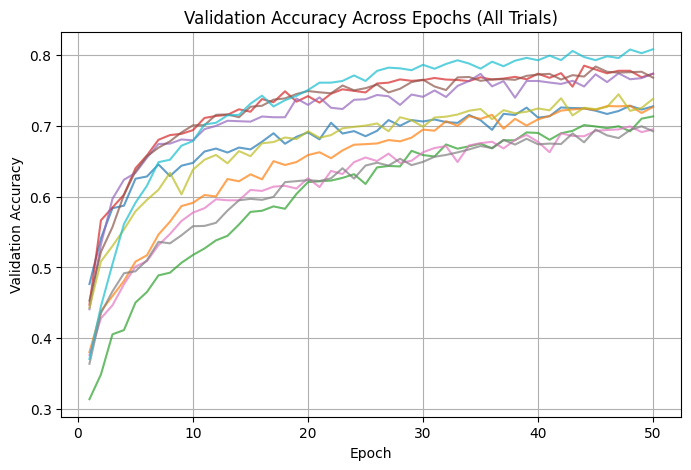

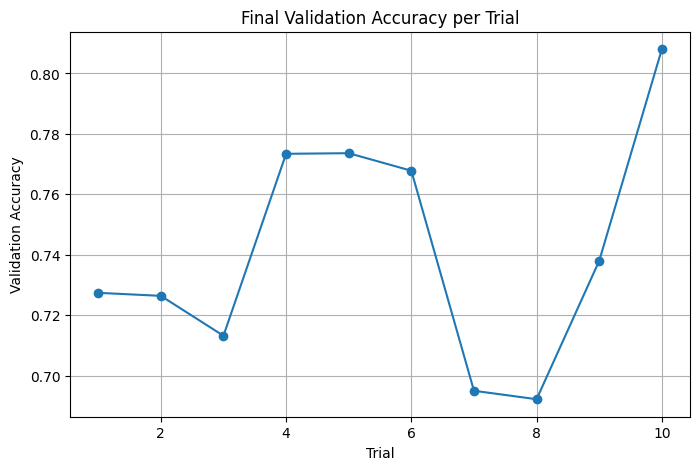

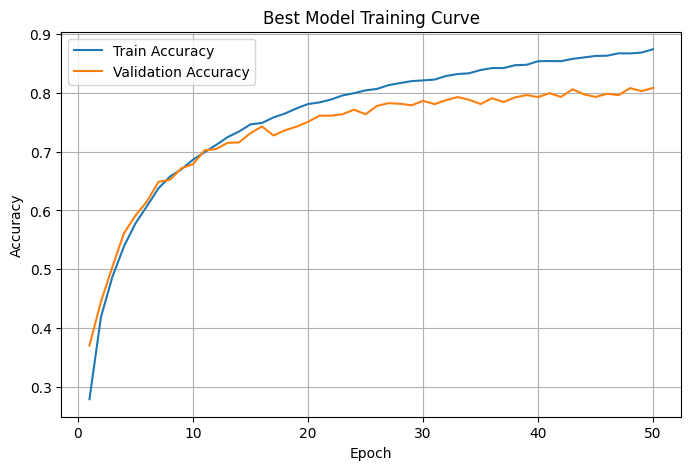

(   trial  num_layers               filters          kernels activation  \
 0     10           5  [64, 32, 64, 64, 16]  [5, 5, 5, 5, 5]  LeakyReLU   
 1      5           3          [64, 16, 64]        [5, 3, 3]  LeakyReLU   
 2      4           3          [32, 64, 16]        [3, 5, 5]  LeakyReLU   
 3      6           3          [32, 16, 64]        [3, 5, 5]  LeakyReLU   
 4      9           2              [32, 32]           [5, 5]  LeakyReLU   
 5      1           2              [64, 32]           [3, 3]  LeakyReLU   
 6      2           4      [32, 32, 32, 32]     [3, 5, 3, 3]       ReLU   
 7      3           5  [16, 32, 32, 64, 32]  [3, 3, 3, 3, 5]       ReLU   
 8      7           3          [16, 32, 16]        [5, 5, 3]  LeakyReLU   
 9      8           3          [32, 32, 16]        [3, 3, 3]       ReLU   
 
   pooling  final_train_acc  final_val_acc  
 0     avg         0.873578         0.8080  
 1     max         0.781533         0.7736  
 2     max         0.811956         0.

In [ ]:
df, best_arch_config = random_search(train_loader, val_loader, device, num_trials=10, epochs=50)

Consider Early Stopping for NAS

In [ ]:
def train_with_early_stopping(model, patience=5):
    best_accuracy = 0.0
    stop_counter = 0
    for epoch in range(epochs):
        accuracy = train_and_evaluate(model)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            stop_counter = 0  # Reset patience counter if improvement is seen
        else:
            stop_counter += 1

        # Stop training if no improvement for `patience` epochs
        if stop_counter >= patience:
            print("Stopping early due to no improvement.")
            break

    return best_accuracy

# Gradient Approaches (DARTS)

Since your goal is to predict the best hyperparameters before implementing the full model, your "Predictor" model (the one you write for your paper) could use the average gradient norm of the first 50 iterations as an input feature.

Hypothesis to test: "I can predict the final accuracy of a CIFAR10 model within 90% certainty just by looking at the gradient stability of the first half-epoch.”

If you plot the Gradient Norm (the magnitude of the updates during backward()), you can see:

• Vanishing Gradients: The norm drops to near zero. The model is "stuck" and accuracy will never improve.

• Exploding Gradients: The norm spikes to infinity (NaN). This usually happens when your Learning Rate is too high for the Batch Size.

Testing Kernel, Activation Function, and Pooling w DARTS (cannot change filters or layer num)

In [ ]:
#---------------Defining Limited Search Space------------------

class SearchSpace():
    def __init__(self):
        self.num_layers = 5
        self.fixed_filters = [64, 32, 64, 64, 16]

    def sample(self):
        return {
            "num_layers": self.num_layers,
            "filters": self.fixed_filters
        }


In [ ]:
#------------Define Class for Mixed Optimization with Weights---------------

class MixedOptim(nn.Module):
    def __init__(self, ops):
        super().__init__()
        self.ops = nn.ModuleList(ops)
        self.alpha = nn.Parameter(torch.zeros(len(ops)))  # learnable arch weights

    def forward(self, x):
        w = F.softmax(self.alpha, dim=0)
        return sum(wi * op(x) for wi, op in zip(w, self.ops))

In [ ]:
#----------------Defining Evaluate Function-----------------
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc

In [ ]:
#------------Define Class for DARTS Optimization with Config--------------------

class DARTSFromConfig(nn.Module):
    """
    Uses config["num_layers"] and config["filters"] as the backbone.
    Learns (via gradient) which kernel/activation/pooling to use at each layer.
    """
    def __init__(self, config, num_classes=10):
        super().__init__()
        self.config = config

        # num layers and filters are fixed
        self.num_layers = config["num_layers"]
        filters = config["filters"]

        in_ch = 3 # RGB
        spatial = 32 # 32 pixels

        self.blocks = nn.ModuleList()
        self.pool_ops = nn.ModuleList()

        # store references to architecture parameters
        self._arch_params = []

        for i in range(self.num_layers):
            out_ch = filters[i]

            # conv+activation search (4 options)
            conv_ops = [
                nn.Sequential(nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False), nn.ReLU()),
                nn.Sequential(nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False), nn.LeakyReLU(0.1)),
                nn.Sequential(nn.Conv2d(in_ch, out_ch, 5, padding=2, bias=False), nn.ReLU()),
                nn.Sequential(nn.Conv2d(in_ch, out_ch, 5, padding=2, bias=False), nn.LeakyReLU(0.1)),
            ]
            mixed_conv = MixedOptim(conv_ops)
            self.blocks.append(mixed_conv)
            self._arch_params.append(mixed_conv.alpha)

            # pooling search (2 options)
            pool_ops = [nn.AvgPool2d(2), nn.MaxPool2d(2)]
            mixed_pool = MixedOptim(pool_ops)
            self.pool_ops.append(mixed_pool)
            self._arch_params.append(mixed_pool.alpha)

            in_ch = out_ch
            spatial //= 2

        self.classifier = nn.Linear(in_ch * spatial * spatial, num_classes)

    def forward(self, x):
        for conv, pool in zip(self.blocks, self.pool_ops):
            x = conv(x)
            x = pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

    def arch_parameters(self):
        return self._arch_params

    def weight_parameters(self):
        arch_set = set(self._arch_params)
        return [p for p in self.parameters() if p not in arch_set]


In [ ]:
#-------------DARTS Training Epoch Function-------------------

def train_one_epoch_darts(model, train_loader, val_loader, w_optim, arch_optim, criterion, device, grad_clip=None):
    model.train()
    val_iter = iter(val_loader)

    running_loss = 0.0
    correct = 0
    total = 0

    grad_norm_sum = 0.0
    grad_norm_count = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # (A) update architecture params on validation batch
        try:
            v_images, v_labels = next(val_iter)
        except StopIteration:
            val_iter = iter(val_loader)
            v_images, v_labels = next(val_iter)

        v_images, v_labels = v_images.to(device), v_labels.to(device)

        arch_optim.zero_grad(set_to_none=True)
        v_logits = model(v_images)
        arch_loss = criterion(v_logits, v_labels)
        arch_loss.backward()
        arch_optim.step()

        # (B) update weights on training batch
        w_optim.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()

        if grad_clip is not None:
            nn.utils.clip_grad_norm_(model.weight_parameters(), grad_clip)

        # ---- gradient magnitude (L2 norm) for this batch ----
        total_norm_sq = 0.0
        for p in model.weight_parameters():  # weights only is usually what you want
            if p.grad is not None:
                param_norm = p.grad.data.norm(2).item()
                total_norm_sq += param_norm ** 2
        batch_grad_norm = total_norm_sq ** 0.5

        grad_norm_sum += batch_grad_norm
        grad_norm_count += 1

        w_optim.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    acc = correct / total
    avg_grad_norm = grad_norm_sum / max(1, grad_norm_count)

    return avg_loss, acc, avg_grad_norm


In [ ]:
#-------------Defining Plotting Function for Gradient----------------

def plot_results_with_grads(results):
    # Plot 1: all models across epochs (val acc)
    plt.figure(figsize=(8,5))
    for r in results:
        plt.plot(range(1, len(r["val_history"]) + 1), r["val_history"], alpha=0.6)
    plt.title("Validation Accuracy Across Epochs (All Trials)")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.legend([f"Trial {r['trial']}" for r in results])
    plt.grid(True)
    plt.show()

    # Plot 2: best model train vs val + gradient norm overlay
    best_result = max(results, key=lambda x: x["val_acc"])

    epochs = range(1, len(best_result["train_history"]) + 1)

    fig, ax1 = plt.subplots(figsize=(8,5))

    ax1.plot(epochs, best_result["train_history"], label="Train Accuracy")
    ax1.plot(epochs, best_result["val_history"], label="Validation Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.grid(True)

    # second axis for gradients
    ax2 = ax1.twinx()
    ax2.plot(epochs, best_result["grad_history"], linestyle="--", label="Grad Norm (weights)")
    ax2.set_ylabel("Gradient Norm")

    # combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

    plt.title("Best Model: Accuracy + Gradient Norm Across Epochs")
    plt.show()

In [ ]:
#-----------------Defining Function to Output Learned Choices-----------------

def extract_learned_choices(model):
    """
    Returns a readable summary of which ops were selected (argmax) per layer.
    For conv MixedOp: 0=3x3+ReLU, 1=3x3+Leaky, 2=5x5+ReLU, 3=5x5+Leaky
    For pool MixedOp: 0=avg, 1=max
    """
    summary = []
    for layer_idx, (conv_mixed, pool_mixed) in enumerate(zip(model.blocks, model.pool_ops), start=1):
        conv_choice = torch.argmax(F.softmax(conv_mixed.alpha.detach(), dim=0)).item()
        pool_choice = torch.argmax(F.softmax(pool_mixed.alpha.detach(), dim=0)).item()

        conv_map = {
            0: "Conv3+ReLU",
            1: "Conv3+LeakyReLU",
            2: "Conv5+ReLU",
            3: "Conv5+LeakyReLU"
        }
        pool_map = {0: "AvgPool", 1: "MaxPool"}

        summary.append(f"L{layer_idx}:{conv_map[conv_choice]}+{pool_map[pool_choice]}")
    return " | ".join(summary)

In [ ]:
#-----------Defining Gradient Search Function----------------

def gradient_nas_search(
    train_loader,
    val_loader,
    device,
    num_trials=5,
    epochs=5
):
    search_space = SearchSpace()
    criterion = nn.CrossEntropyLoss()

    rows = []       # for the dataframe
    results = []    # for plotting (histories)
    best_val = -1
    best_info = None

    for trial in range(num_trials):
        print(f"Trial {trial + 1}/{num_trials}")
        config = search_space.sample()  # depth + filters sampled

        model = DARTSFromConfig(config).to(device)

        w_optim = torch.optim.SGD(
            model.weight_parameters(), lr=0.025, momentum=0.9, weight_decay=3e-4
        )
        arch_optim = torch.optim.Adam(
            model.arch_parameters(), lr=3e-4, betas=(0.5, 0.999), weight_decay=1e-3
        )

        train_hist, val_hist, grad_hist = [], [], []

        for ep in range(epochs):
            tr_loss, tr_acc, avg_grad_norm = train_one_epoch_darts(
                model, train_loader, val_loader, w_optim, arch_optim, criterion, device
            )
            v_loss, v_acc = evaluate(model, val_loader, criterion, device)

            train_hist.append(tr_acc)
            val_hist.append(v_acc)
            grad_hist.append(avg_grad_norm)

        final_train_acc = train_hist[-1]
        final_val_acc = val_hist[-1]

        # Extract learned discrete choices (argmax) for readability
        learned = extract_learned_choices(model)

        # ---- DF row ----
        rows.append({
            "trial": trial + 1,
            "num_layers": config["num_layers"],
            "filters": str(config["filters"]),
            "final_train_acc": final_train_acc,
            "final_val_acc": final_val_acc,
            "learned_ops": learned
        })

        # ---- Plotting result ----
        results.append({
            "trial": trial + 1,
            "config": config,
            "val_acc": final_val_acc,
            "train_history": train_hist,
            "val_history": val_hist,
            "grad_history": grad_hist,
            "learned_ops": learned
        })

        if final_val_acc > best_val:
            best_val = final_val_acc
            best_info = (config, learned)

    plot_results_with_grads(results)
    print("Table of Selected Models from Gradient Search DARTS: Sorted by Validation Accuracy")
    print("--------------------------------------------------------------------------------------")

    df = (
        pd.DataFrame(rows)
        .sort_values("final_val_acc", ascending=False)
        .reset_index(drop=True)
    )

    return df, best_info, results


In [ ]:
df, best_info, results = gradient_nas_search(train_loader, val_loader, device, num_trials = 10, epochs = 50)

Trial 1/10
Trial 2/10
Trial 3/10
Trial 4/10
Trial 5/10


In [ ]:
best_arch_config = best_info[0]

edit best_info to be

# Bayesian Optimization/ Hyperparameter Tuning

can easily extend this to bayesian optimization

In [ ]:
#-------------Define Train One Epoch Bayesian Function-------------------

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total, correct, total_loss = 0, 0, 0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)

    return total_loss / total, correct / total

@torch.no_grad()
def eval_accuracy(model, loader, device):
    model.eval()
    total, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return correct / total

In [ ]:
#---------------Defining Build Functions---------------

def build_model(config):
    layers = []
    in_channels = 3
    spatial_size = 32  # CIFAR-10

    for i in range(config["num_layers"]):
        k = config["kernels"][i]
        f = config["filters"][i]

        layers.append(nn.Conv2d(in_channels, f, kernel_size=k, padding=k // 2))
        layers.append(config["activation"]())  # instantiate activation module
        if config["pooling"] == "avg":
            layers.append(nn.AvgPool2d(2))
        else:
            layers.append(nn.MaxPool2d(2))

        in_channels = f
        spatial_size //= 2

    layers.append(nn.Flatten())
    layers.append(nn.Linear(in_channels * spatial_size * spatial_size, 10))

    return nn.Sequential(*layers)

def model_builder(params):
    model = build_model(best_arch_config).to(device)
    return model

In [ ]:
#--------------Define Hyperparamter Search Space---------------

def search_space_BO(trial):
    return {
        "lr": trial.suggest_float("lr", 1e-4, 3e-2, log=True), # lower and upper bounds
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True), # lower and upper bounds
        "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128]),
        "optimizer": trial.suggest_categorical("optimizer", ["adamw", "sgd"]),
        "momentum": trial.suggest_float("momentum", 0.8, 0.99),  # only used if SGD # lower and upper bound
    }

In [ ]:
#---------------Evaluate Function---------------------

def evaluate_fn_BO(make_train_loader, val_loader, device, epochs=8):
    def evaluate_fn(model, params):
        train_loader = make_train_loader(params["batch_size"])

        if params["optimizer"] == "adamw":
            optimizer = torch.optim.AdamW(
                model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"]
            )
        else:
            optimizer = torch.optim.SGD(
                model.parameters(), lr=params["lr"],
                momentum=params["momentum"], weight_decay=params["weight_decay"]
            )

        best_val = 0.0
        for _ in range(epochs):
            train_one_epoch(model, train_loader, optimizer, device)
            val_acc = eval_accuracy(model, val_loader, device)
            best_val = max(best_val, val_acc)
        return best_val

    return evaluate_fn

In [ ]:
#-------------Define Hyperparamter Search Function--------------

def hyperparameter_search(
    model_builder,          # params -> model
    evaluate_fn,            # model, params -> val_acc
    search_space_spec,      # trial -> params dict
    n_trials=2,
    seed=42
):
    trial_rows = []
    best_model = {"model": None}
    best_score = {"score": float("-inf")}

    def objective(trial):
        # 1) Sample hyperparameters
        params = search_space_BO(trial)

        # 2) Build model
        model = model_builder(params)

        # 3) Evaluate
        val_acc = float(evaluate_fn(model, params))

        # Track best
        if val_acc > best_score["score"]:
            best_score["score"] = val_acc
            best_model["model"] = model

        # Log trial
        trial_rows.append({
            "trial": trial.number,
            "val_acc": val_acc,
            **params
        })

        return val_acc

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=seed),
    )

    study.optimize(objective, n_trials=n_trials)

    # ---- Create DataFrame ----
    df = pd.DataFrame(trial_rows).sort_values("trial").reset_index(drop=True)

    # ---- Plot optimization progress ----
    if not df.empty:
        best_so_far = df["val_acc"].cummax()

        plt.figure()
        plt.plot(df["trial"], df["val_acc"], marker="o", label="Val Acc")
        plt.plot(df["trial"], best_so_far, linestyle="--", label="Best So Far")
        plt.scatter(
            df.loc[df["val_acc"].idxmax(), "trial"],
            df["val_acc"].max(),
            s=120,
            label="Best Trial"
        )
        plt.xlabel("Trial")
        plt.ylabel("Validation Accuracy")
        plt.title("Bayesian Optimization Progress")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return best_model["model"], best_score["score"], df, study

In [ ]:
#---------------Running Tests--------------------

# Defining Data Inputs
train_subset, val_subset = random_split(train_dataset.dataset.data, [train_size, val_size])

def make_train_loader(batch_size):
    return DataLoader(train_subset, batch_size=batch_size, shuffle=True)

def make_val_loader(batch_size=128):
    return DataLoader(val_subset, batch_size=batch_size, shuffle=False)

val_loader = make_val_loader(128)

model_builder = model_builder(best_arch_config, device)
evaluate_fn = evaluate_fn_BO(make_train_loader, val_loader, device, epochs=2)

best_model, best_score, df_trials, study = hyperparameter_search(
    model_builder=model_builder,
    evaluate_fn=evaluate_fn,
    search_space_spec=search_space_BO,
    n_trials=30,
    plot=True
)

print("Best val acc:", best_score)
print(df_trials.head())

TypeError: model_builder.<locals>.model_builder() takes 1 positional argument but 2 were given

# Final Testing Data Training

## Time per Trial

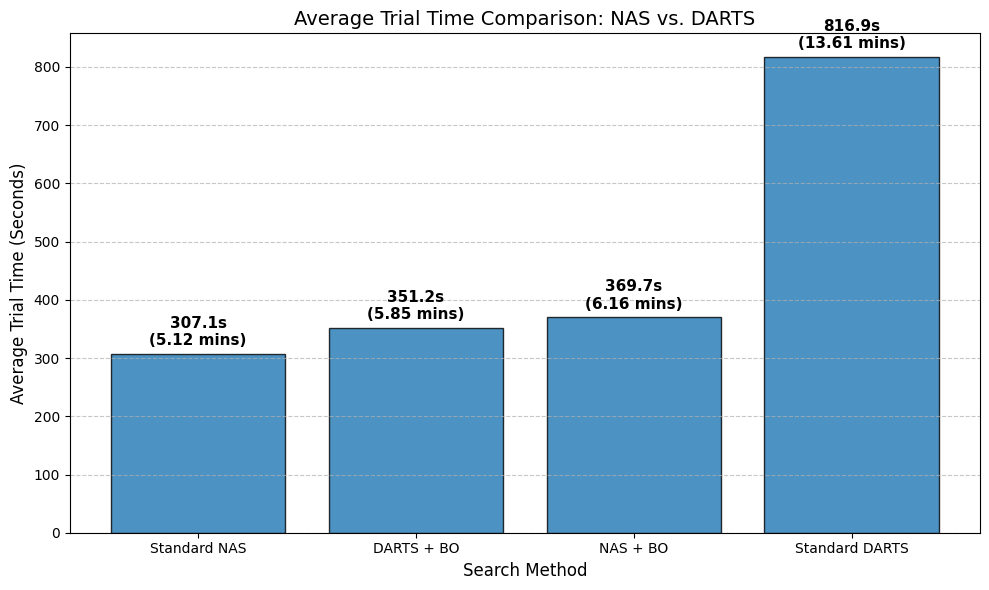

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

darts_file = 'DARTS_Output_Table (1).csv'
darts_bo_file = 'BO_Output_Table_DARTS.csv'
nas_file = 'NAS_Random_Search_Table.csv'
nas_bo_file = 'BO_Output_Table_NAS.csv'

nas_df = pd.read_csv(nas_file)
nas_bo_df = pd.read_csv(nas_bo_file)
darts_df = pd.read_csv(darts_file)
darts_bo_df = pd.read_csv(darts_bo_file)

avg_times = {
    'Standard NAS': nas_df['trial_time_sec'].mean(),
    'NAS + BO': nas_bo_df['trial_time_sec'].mean(),
    'Standard DARTS': darts_df['trial_time_sec'].mean(),
    'DARTS + BO': darts_bo_df['trial_time_sec'].mean()
}

# Sort the data for the bar chart from fastest to slowest
sorted_items = sorted(avg_times.items(), key=lambda x: x[1])
sorted_methods = [item[0] for item in sorted_items]
sorted_times = [item[1] for item in sorted_items]

# # Map consistent colors
# color_map = {'Standard NAS': 'green', 'NAS + BO': 'red', 'Standard DARTS': 'blue', 'DARTS + BO': 'orange'}
# colors = [color_map[m] for m in sorted_methods]

plt.figure(figsize=(10, 6))
bars = plt.bar(sorted_methods, sorted_times, edgecolor='black', alpha=0.8)

# Add exact second values on top of the bars
for bar in bars:
    yval = bar.get_height()
    mins = yval / 60
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10,
             f'{yval:.1f}s\n({mins:.2f} mins)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.title('Average Trial Time Comparison: NAS vs. DARTS', fontsize=14)
plt.ylabel('Average Trial Time (Seconds)', fontsize=12)
plt.xlabel('Search Method', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#